# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dipson-mishra/flyrank-ml/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

**Task Type:** Ranking / Scoring.

**Why:** The goal is not to simply categorize pages as "bad" or "good," but to prioritize them for an editor's limited time. We need a continuous score that represents the "opportunity magnitude"—the delta between the current observed CTR and the expected CTR for that page's position and content type. A ranking approach allows us to build a prioritized review queue.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Target or proxy

**Target:** CTR Opportunity Gap.

**Source:** This is a **defined rule (proxy)** for the framing stage. We will target pages that meet two observed conditions:
1. **High Visibility:** `impressions_90d >= 500` (ensures the signal is not noise).
2. **Low Engagement:** `ctr < 0.5%` (indicates a significant gap in capture rate).

In the final model, the target will be the actual observed CTR, and the "opportunity" will be the residual difference between observed and predicted CTR.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Success metric

**Metric:** Precision@50.

**Why:** Editorial capacity is the primary constraint. If the team can review 50 pages per cycle, the most valuable model is the one that ensures those 50 pages are the most promising candidates. Precision@50 directly measures the hit rate of the top of the queue: "Of the 50 pages we recommended, how many actually had a visibility-engagement gap?"

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. The unit of analysis, as a real dataframe

**Unit of Analysis:** One row = one pseudonymized content item.

The dataframe contains 90-day aggregated metrics for each item, which is the correct grain for making a "refresh" or "optimization" decision.

In [9]:
import os
import pandas as pd

# Self-contained path resolution: works no matter what cell ran before,
# and no matter what folder Jupyter happens to launch from.
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))
csv_path = os.path.join(project_root, "data", "raw", "content_refresh_anonymized.csv")

df = pd.read_csv(csv_path)

# Show the unit of analysis: one row per content item
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the unit of analysis:")
display(df[['content_id', 'client_id', 'impressions_90d', 'ctr', 'avg_position']].head())

Dataset shape: (30000, 44)

First 5 rows of the unit of analysis:


,content_id,client_id,impressions_90d,ctr,avg_position
0,content_304f48230142,client_f369cb89fc,3803,0.76,10.6
1,content_a1fb4e703a9e,client_4e07408562,15320,0.05,20.3
2,content_9aa793d4d895,client_7f2253d7e2,12581,0.09,36.5
3,content_331d6c4de07b,client_19581e27de,11751,0.49,6.2
4,content_d99b7a2d90ca,client_3fdba35f04,19140,0.13,44.0


## 5. Why ML beats a fixed rule here

A fixed rule like `CTR < 0.5%` is too blunt because **expected CTR is not constant**. 

1. **Position Bias**: A page at position 10 naturally has a lower CTR than a page at position 1. A rule that flags all pages < 0.5% will be flooded with low-position pages (false positives) and miss high-position pages that are underperforming their tier (false negatives).
2. **Content Type Variance**: Different types of content (e.g., "How-to" vs "Product Page") have different baseline engagement patterns.
3. **Interaction Effects**: The opportunity is likely a complex interaction between position, content type, and volume.

ML (specifically a regression or ranking model) can learn the "baseline" CTR for every combination of position and type, allowing us to flag pages based on their **deviation from the norm** rather than a global threshold.

Mean CTR by Position Tier:
position_tier
deep        0.150212
page_3_5    0.222484
striking    0.323239
page_1      0.652467
top_3       1.483611
Name: ctr, dtype: float64


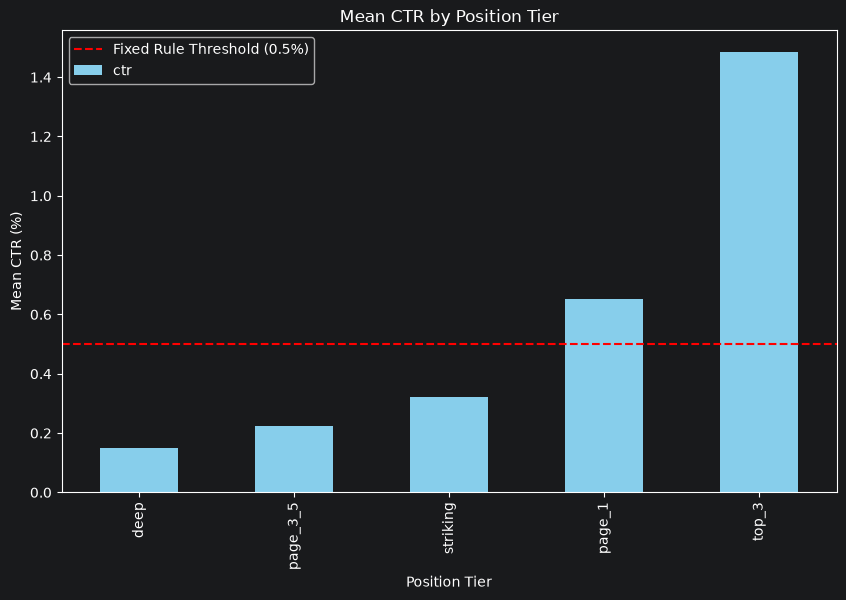


Observation: The mean CTR varies significantly by tier. A fixed threshold of 0.5% would incorrectly flag almost all pages in the lower tiers, regardless of whether they are 'underperforming' for their specific position.


In [10]:
# Demonstrate why a fixed rule is insufficient by showing CTR distribution by position tier
import matplotlib.pyplot as plt

# Calculate mean CTR by position tier
ctr_by_pos = df.groupby('position_tier')['ctr'].mean().sort_values()

print("Mean CTR by Position Tier:")
print(ctr_by_pos)

plt.figure(figsize=(10, 6))
ctr_by_pos.plot(kind='bar', color='skyblue')
plt.axhline(y=0.5, color='r', linestyle='--', label='Fixed Rule Threshold (0.5%)')
plt.title("Mean CTR by Position Tier")
plt.ylabel("Mean CTR (%)")
plt.xlabel("Position Tier")
plt.legend()
plt.show()

print("\nObservation: The mean CTR varies significantly by tier. A fixed threshold of 0.5% would incorrectly flag almost all pages in the lower tiers, regardless of whether they are 'underperforming' for their specific position.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.